In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import pandas as pd

In [6]:
file_path="/content/drive/MyDrive/Data Mining/ecommerce_customers.csv"

In [7]:
df=pd.read_csv(file_path)

In [9]:
df.head()

,CustomerID,Age,Annual_Income_USD,Site_Visits,Total_Spent_USD
0,1,45,120000,12,4500
1,2,42,115000,14,4200
2,3,48,130000,10,4800
3,4,41,110000,15,4100
4,5,47,125000,11,4600


In [10]:
X=df.iloc[:,1:].values

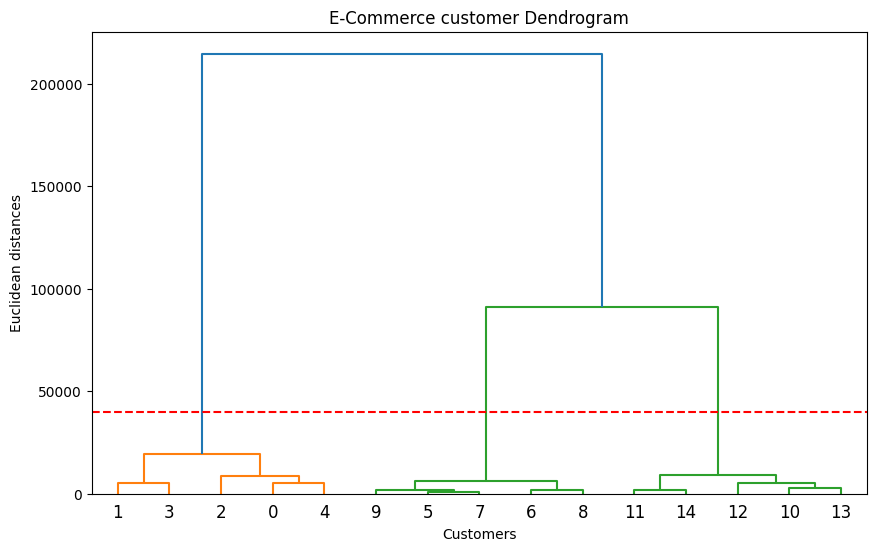

In [11]:
plt.figure(figsize=(10,6))
dendrogram=sch.dendrogram(sch.linkage(X,method='ward'))
plt.title('E-Commerce customer Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.axhline(y=40000,color='r',linestyle='--')
plt.show()

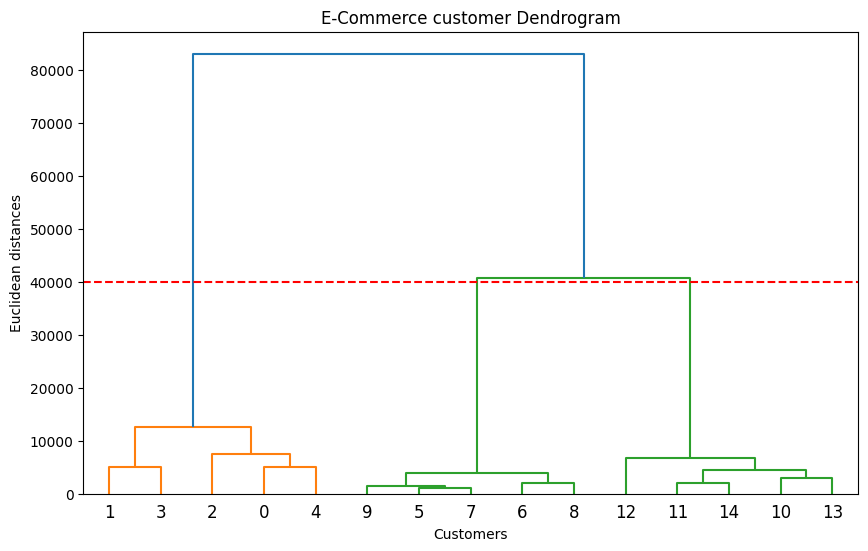

In [12]:
plt.figure(figsize=(10,6))
dendrogram=sch.dendrogram(sch.linkage(X,method='centroid'))
plt.title('E-Commerce customer Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.axhline(y=40000,color='r',linestyle='--')
plt.show()

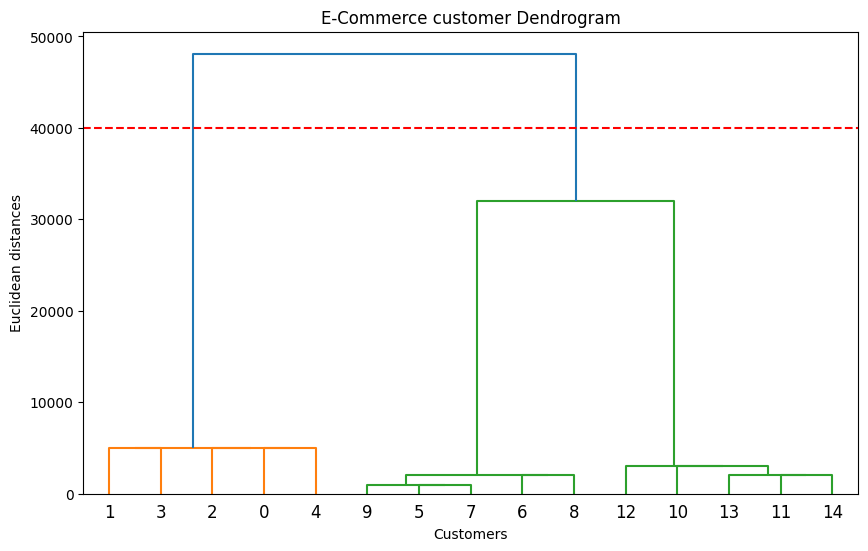

In [13]:
plt.figure(figsize=(10,6))
dendrogram=sch.dendrogram(sch.linkage(X,method='single'))
plt.title('E-Commerce customer Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.axhline(y=40000,color='r',linestyle='--')
plt.show()

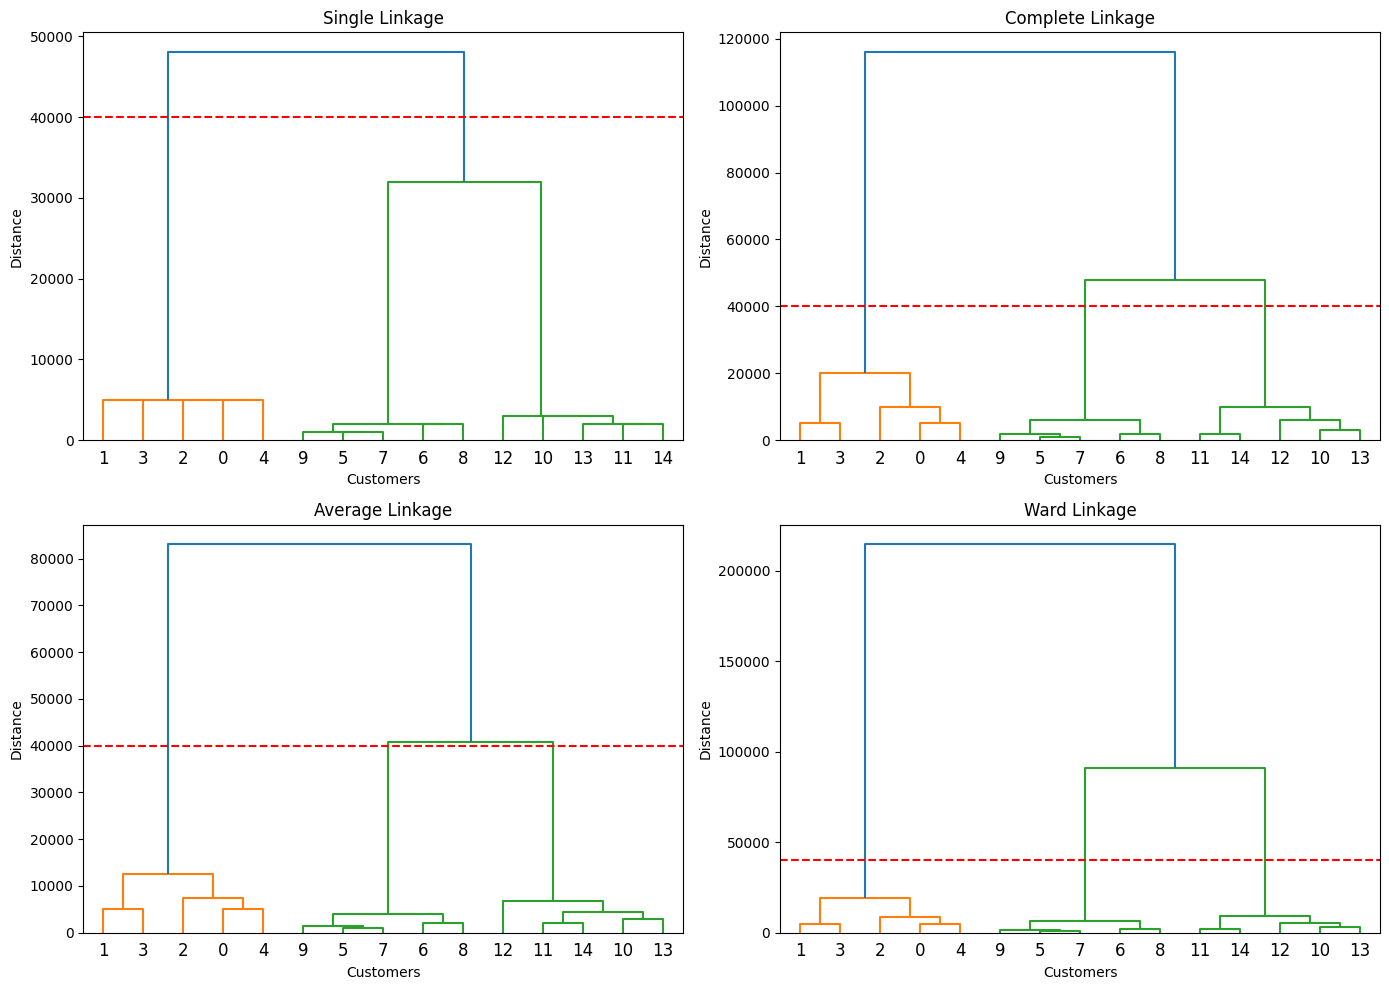

In [17]:
methods = ["single", "complete", "average", "ward"]

plt.figure(figsize=(14, 10))

for i, method in enumerate(methods, 1):
    plt.subplot(2, 2, i)

    sch.dendrogram(sch.linkage(X, method=method))

    plt.title(f"{method.capitalize()} Linkage")
    plt.xlabel("Customers")
    plt.ylabel("Distance")

    plt.axhline(y=40000, color='r', linestyle='--')

plt.tight_layout()
plt.show()

In [18]:
from scipy.cluster.hierarchy import fcluster

clusters = fcluster(sch.linkage(X, method='ward'), t=40000, criterion='distance')

In [19]:
clusters = fcluster(sch.linkage(X, method='ward'), t=4, criterion='maxclust')

In [20]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, clusters)
print(score)

0.7563081782217025


In [23]:
from scipy.cluster.hierarchy import linkage, cophenet
from scipy.spatial.distance import pdist

methods = ["single", "complete", "average", "ward"]

for m in methods:
    Z = linkage(X, method=m)
    c, _ = cophenet(Z, pdist(X))
    print(f"{m}: {c:.4f}")

single: 0.8918
complete: 0.9053
average: 0.9086
ward: 0.9072


In [25]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for m in methods:
    model = AgglomerativeClustering(n_clusters=4, linkage=m)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"{m}: {score:.4f}")

single: 0.7563
complete: 0.7563
average: 0.7563
ward: 0.7563
